# **Persistence**

In [49]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [68]:
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [69]:
class JokeState(TypedDict):
    
    topic: str 
    joke: str 
    explanation: str 

In [70]:
def generate_joke(state: JokeState):
    
    prompt = f"generate a joke on the topic: {state['topic']}"
    response = model.invoke(prompt).content 
    
    print('joke :',response)
    return {'joke':response}

In [71]:
def generate_explanation(state: JokeState):
    
    prompt = f"write an explanation for the joke: {state['joke']}"
    response = model.invoke(prompt).content 
    
    print('explanation: ',response)
    return {'explanation':response}

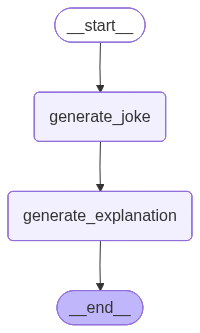

In [72]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [73]:
config1 = {'configurable':{'thread_id':'1'}}
workflow.invoke({'topic':'pizza'},config=config1)

joke : [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can feed a family of four.', 'extras': {'signature': 'EoMSCoASAb4+9vtj9a1Be9US3H4SdudsX+HyWn2sk4aiYLuJXv8OSP/Xa7qpDZZFRxT1vtAf4RBJu0465J8IMTHlBpR3c+QOd7UYDAmz5xj7oYI4usFKo0QKlwEr1xz+slThHRJ8wD88YpS/vHGAzALxM206GBtQ8p21k1W8LPySPxWamsoY+02QVzuoXHiObUDqZNdlWeN7jsqXylps29hAE/YUgbPAFn5JQ+JZ6luSfYklXAqb0m987ou0XLF8HNPz+c9mw3FSplEPKTZ5bU3fR0mrKX1s8AxcEnD4qRJbnFQ1rkvV9jKvHTSPlQJ4roEQmlQJvkN5jmUB8ogi/fHqjr5pVbkTcmyrLIBjm9DJUiQXJ/S3OVrnFwEx8T/26paYXF/v6pv8vj4D4dNiLnQgd2v9L76tkiZ7rO6MouV6+ABqKrVeCHSrldGkbvf65S4twDRpS5GTczaq3AY2rHWyW/0TTKGgSY4FWnhbDZF0V8L/ktKMYnNPGmmdDKkDJbDfGnPT9MySwKoWo3DLi7/W+W/VG7PTMXwdzgP9CtuxGjtuPxaVWD2JyrVaY+Pf1zukxji2rAJH14REypdQ+WHx+hUfdG+WE0uHcNhT3vrKex8FZXiB0M45N+eBV0l6Bo/qupx8dccvMn54/jD+tBA4puBuDTMUvQu+eXiiM/282CT+/+lqE3KC91BJjQDrKyW9rJHt/Zb54SknxQHRxhQhBm/5v8HPUPE9CnJ8HuNksNku4ZDAzQB6i3GgOrLvSHtgOEToq8ziMdrbyB9+FayJQ9SnmSla5WIAW4XiiIqkAAQCrjgS7qVpZ67LTlmFh+DZK96l+lry5fKQt

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can feed a family of four.',
   'extras': {'signature': 'EoMSCoASAb4+9vtj9a1Be9US3H4SdudsX+HyWn2sk4aiYLuJXv8OSP/Xa7qpDZZFRxT1vtAf4RBJu0465J8IMTHlBpR3c+QOd7UYDAmz5xj7oYI4usFKo0QKlwEr1xz+slThHRJ8wD88YpS/vHGAzALxM206GBtQ8p21k1W8LPySPxWamsoY+02QVzuoXHiObUDqZNdlWeN7jsqXylps29hAE/YUgbPAFn5JQ+JZ6luSfYklXAqb0m987ou0XLF8HNPz+c9mw3FSplEPKTZ5bU3fR0mrKX1s8AxcEnD4qRJbnFQ1rkvV9jKvHTSPlQJ4roEQmlQJvkN5jmUB8ogi/fHqjr5pVbkTcmyrLIBjm9DJUiQXJ/S3OVrnFwEx8T/26paYXF/v6pv8vj4D4dNiLnQgd2v9L76tkiZ7rO6MouV6+ABqKrVeCHSrldGkbvf65S4twDRpS5GTczaq3AY2rHWyW/0TTKGgSY4FWnhbDZF0V8L/ktKMYnNPGmmdDKkDJbDfGnPT9MySwKoWo3DLi7/W+W/VG7PTMXwdzgP9CtuxGjtuPxaVWD2JyrVaY+Pf1zukxji2rAJH14REypdQ+WHx+hUfdG+WE0uHcNhT3vrKex8FZXiB0M45N+eBV0l6Bo/qupx8dccvMn54/jD+tBA4puBuDTMUvQu+eXiiM/282CT+/+lqE3KC91BJjQDrKyW9rJHt/Zb54SknxQHRxhQhBm/5v8HPUPE9CnJ8HuNksNku4ZDAzQB6i3GgOrLvSHtgOEToq8ziMdrbyB9+FayJQ9SnmSla5WIAW4XiiIqkAAQCrjgS7q

In [74]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can feed a family of four.', 'extras': {'signature': 'EoMSCoASAb4+9vtj9a1Be9US3H4SdudsX+HyWn2sk4aiYLuJXv8OSP/Xa7qpDZZFRxT1vtAf4RBJu0465J8IMTHlBpR3c+QOd7UYDAmz5xj7oYI4usFKo0QKlwEr1xz+slThHRJ8wD88YpS/vHGAzALxM206GBtQ8p21k1W8LPySPxWamsoY+02QVzuoXHiObUDqZNdlWeN7jsqXylps29hAE/YUgbPAFn5JQ+JZ6luSfYklXAqb0m987ou0XLF8HNPz+c9mw3FSplEPKTZ5bU3fR0mrKX1s8AxcEnD4qRJbnFQ1rkvV9jKvHTSPlQJ4roEQmlQJvkN5jmUB8ogi/fHqjr5pVbkTcmyrLIBjm9DJUiQXJ/S3OVrnFwEx8T/26paYXF/v6pv8vj4D4dNiLnQgd2v9L76tkiZ7rO6MouV6+ABqKrVeCHSrldGkbvf65S4twDRpS5GTczaq3AY2rHWyW/0TTKGgSY4FWnhbDZF0V8L/ktKMYnNPGmmdDKkDJbDfGnPT9MySwKoWo3DLi7/W+W/VG7PTMXwdzgP9CtuxGjtuPxaVWD2JyrVaY+Pf1zukxji2rAJH14REypdQ+WHx+hUfdG+WE0uHcNhT3vrKex8FZXiB0M45N+eBV0l6Bo/qupx8dccvMn54/jD+tBA4puBuDTMUvQu+eXiiM/282CT+/+lqE3KC91BJjQDrKyW9rJHt/Zb54SknxQHRxhQhBm/5v8HPUPE9CnJ8HuNksNku4ZDAzQB6i3GgOrLvSHtgOEToq8ziMdrbyB9+FayJQ9SnmSla5WIAW4X

In [75]:
config2 = {'configurable':{'thread_id':'3'}}
workflow.invoke({'topic':'sandwich'},config=config2)

joke : [{'type': 'text', 'text': 'Why did the sandwich go to the doctor?\n\nBecause it was feeling a bit **crumby**.', 'extras': {'signature': 'EuoYCucYAb4+9vvffIfkbyXVWVqBx12fwaMsZEfqaMWvjkv6Stz82hlbxsQqU9HBsTmiuJG+rhs+2r5qLTChlIm9H5MbmDEBh1mFk8oHMuOxUiL9zoi5BPwObzCnSqjM5A29V7Ye6monORShgkcQi6MW8rLXhm+1pESHmRP7w7yvCI0ChdlFTtkbsfA/IJqIyYIVAYfDxjJXwE+Lq/X6xJoWC10yTVrphxtvBlq15mRrOOoU5pVT/iVa/Acsu23cAHgtwuR8t/o+9uGCIR7HGzEGF2x6cYpMfCoBGf2KFBQle830CgX7hVhBh1cg8Y5h034T8pa6ttmayPRFyfa38N5PsS1Bw9IhIGZ32GRqaj3S5HkbFNoBVLYX/ia/gbaQ9ZtIv6opz1dvBtS11Ds9MbMPn0WyykkbQzSnh//aok3Mxtp+BV0p0vlep+hogv+rwYAfDlHwVSq2Ec9NRpanKUiGzrdUefyBe5RBn3NozvrrM3Ry+63mSuNtKi8PiRLThNx2xHsMyC5GrhpAAjPzkt9cw9wGcIagpKAg7UBOPDXTfDzMeXRa9YvhoM9NWXpDW4mLhsJRmAuvv6CGkECJr2jV5ELg/XRXBOiIojaZVTZbjGS9tqZvRqLp2aVzJMl6CYk8HJkvBbPQd2trSDboZ5pnJgvRZvWn9u3W76shQ+PEprAJ+74IetH+JjBNU38gxQSffyd17najBJTnKfI9lUQQU20LNTJkdiYo7OftX6Awk8cna4OeRe0JEu0eVKFAeozfMT6xM5VshK1B4372GCqdv14of3IXOAfhjMh4uMFvdUe4EDkDHLp9DrujhoLBsY/Q81a86xGCcuLdIjeuz3R9

{'topic': 'sandwich',
 'joke': [{'type': 'text',
   'text': 'Why did the sandwich go to the doctor?\n\nBecause it was feeling a bit **crumby**.',
   'extras': {'signature': 'EuoYCucYAb4+9vvffIfkbyXVWVqBx12fwaMsZEfqaMWvjkv6Stz82hlbxsQqU9HBsTmiuJG+rhs+2r5qLTChlIm9H5MbmDEBh1mFk8oHMuOxUiL9zoi5BPwObzCnSqjM5A29V7Ye6monORShgkcQi6MW8rLXhm+1pESHmRP7w7yvCI0ChdlFTtkbsfA/IJqIyYIVAYfDxjJXwE+Lq/X6xJoWC10yTVrphxtvBlq15mRrOOoU5pVT/iVa/Acsu23cAHgtwuR8t/o+9uGCIR7HGzEGF2x6cYpMfCoBGf2KFBQle830CgX7hVhBh1cg8Y5h034T8pa6ttmayPRFyfa38N5PsS1Bw9IhIGZ32GRqaj3S5HkbFNoBVLYX/ia/gbaQ9ZtIv6opz1dvBtS11Ds9MbMPn0WyykkbQzSnh//aok3Mxtp+BV0p0vlep+hogv+rwYAfDlHwVSq2Ec9NRpanKUiGzrdUefyBe5RBn3NozvrrM3Ry+63mSuNtKi8PiRLThNx2xHsMyC5GrhpAAjPzkt9cw9wGcIagpKAg7UBOPDXTfDzMeXRa9YvhoM9NWXpDW4mLhsJRmAuvv6CGkECJr2jV5ELg/XRXBOiIojaZVTZbjGS9tqZvRqLp2aVzJMl6CYk8HJkvBbPQd2trSDboZ5pnJgvRZvWn9u3W76shQ+PEprAJ+74IetH+JjBNU38gxQSffyd17najBJTnKfI9lUQQU20LNTJkdiYo7OftX6Awk8cna4OeRe0JEu0eVKFAeozfMT6xM5VshK1B4372GCqdv14of3IXOAfhjMh4uMFvdUe4EDkDHLp9Dr

In [76]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'sandwich', 'joke': [{'type': 'text', 'text': 'Why did the sandwich go to the doctor?\n\nBecause it was feeling a bit **crumby**.', 'extras': {'signature': 'EuoYCucYAb4+9vvffIfkbyXVWVqBx12fwaMsZEfqaMWvjkv6Stz82hlbxsQqU9HBsTmiuJG+rhs+2r5qLTChlIm9H5MbmDEBh1mFk8oHMuOxUiL9zoi5BPwObzCnSqjM5A29V7Ye6monORShgkcQi6MW8rLXhm+1pESHmRP7w7yvCI0ChdlFTtkbsfA/IJqIyYIVAYfDxjJXwE+Lq/X6xJoWC10yTVrphxtvBlq15mRrOOoU5pVT/iVa/Acsu23cAHgtwuR8t/o+9uGCIR7HGzEGF2x6cYpMfCoBGf2KFBQle830CgX7hVhBh1cg8Y5h034T8pa6ttmayPRFyfa38N5PsS1Bw9IhIGZ32GRqaj3S5HkbFNoBVLYX/ia/gbaQ9ZtIv6opz1dvBtS11Ds9MbMPn0WyykkbQzSnh//aok3Mxtp+BV0p0vlep+hogv+rwYAfDlHwVSq2Ec9NRpanKUiGzrdUefyBe5RBn3NozvrrM3Ry+63mSuNtKi8PiRLThNx2xHsMyC5GrhpAAjPzkt9cw9wGcIagpKAg7UBOPDXTfDzMeXRa9YvhoM9NWXpDW4mLhsJRmAuvv6CGkECJr2jV5ELg/XRXBOiIojaZVTZbjGS9tqZvRqLp2aVzJMl6CYk8HJkvBbPQd2trSDboZ5pnJgvRZvWn9u3W76shQ+PEprAJ+74IetH+JjBNU38gxQSffyd17najBJTnKfI9lUQQU20LNTJkdiYo7OftX6Awk8cna4OeRe0JEu0eVKFAeozfMT6xM5VshK1B4372GCqdv14of3IXOAfhjMh4uMF

In [77]:
list_item = [config1,config2]
for item in list_item:
    print(list(workflow.get_state_history(item)))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can feed a family of four.', 'extras': {'signature': 'EoMSCoASAb4+9vtj9a1Be9US3H4SdudsX+HyWn2sk4aiYLuJXv8OSP/Xa7qpDZZFRxT1vtAf4RBJu0465J8IMTHlBpR3c+QOd7UYDAmz5xj7oYI4usFKo0QKlwEr1xz+slThHRJ8wD88YpS/vHGAzALxM206GBtQ8p21k1W8LPySPxWamsoY+02QVzuoXHiObUDqZNdlWeN7jsqXylps29hAE/YUgbPAFn5JQ+JZ6luSfYklXAqb0m987ou0XLF8HNPz+c9mw3FSplEPKTZ5bU3fR0mrKX1s8AxcEnD4qRJbnFQ1rkvV9jKvHTSPlQJ4roEQmlQJvkN5jmUB8ogi/fHqjr5pVbkTcmyrLIBjm9DJUiQXJ/S3OVrnFwEx8T/26paYXF/v6pv8vj4D4dNiLnQgd2v9L76tkiZ7rO6MouV6+ABqKrVeCHSrldGkbvf65S4twDRpS5GTczaq3AY2rHWyW/0TTKGgSY4FWnhbDZF0V8L/ktKMYnNPGmmdDKkDJbDfGnPT9MySwKoWo3DLi7/W+W/VG7PTMXwdzgP9CtuxGjtuPxaVWD2JyrVaY+Pf1zukxji2rAJH14REypdQ+WHx+hUfdG+WE0uHcNhT3vrKex8FZXiB0M45N+eBV0l6Bo/qupx8dccvMn54/jD+tBA4puBuDTMUvQu+eXiiM/282CT+/+lqE3KC91BJjQDrKyW9rJHt/Zb54SknxQHRxhQhBm/5v8HPUPE9CnJ8HuNksNku4ZDAzQB6i3GgOrLvSHtgOEToq8ziMdrbyB9+FayJQ9SnmSla5WIAW4X

In [78]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can feed a family of four.', 'extras': {'signature': 'EoMSCoASAb4+9vtj9a1Be9US3H4SdudsX+HyWn2sk4aiYLuJXv8OSP/Xa7qpDZZFRxT1vtAf4RBJu0465J8IMTHlBpR3c+QOd7UYDAmz5xj7oYI4usFKo0QKlwEr1xz+slThHRJ8wD88YpS/vHGAzALxM206GBtQ8p21k1W8LPySPxWamsoY+02QVzuoXHiObUDqZNdlWeN7jsqXylps29hAE/YUgbPAFn5JQ+JZ6luSfYklXAqb0m987ou0XLF8HNPz+c9mw3FSplEPKTZ5bU3fR0mrKX1s8AxcEnD4qRJbnFQ1rkvV9jKvHTSPlQJ4roEQmlQJvkN5jmUB8ogi/fHqjr5pVbkTcmyrLIBjm9DJUiQXJ/S3OVrnFwEx8T/26paYXF/v6pv8vj4D4dNiLnQgd2v9L76tkiZ7rO6MouV6+ABqKrVeCHSrldGkbvf65S4twDRpS5GTczaq3AY2rHWyW/0TTKGgSY4FWnhbDZF0V8L/ktKMYnNPGmmdDKkDJbDfGnPT9MySwKoWo3DLi7/W+W/VG7PTMXwdzgP9CtuxGjtuPxaVWD2JyrVaY+Pf1zukxji2rAJH14REypdQ+WHx+hUfdG+WE0uHcNhT3vrKex8FZXiB0M45N+eBV0l6Bo/qupx8dccvMn54/jD+tBA4puBuDTMUvQu+eXiiM/282CT+/+lqE3KC91BJjQDrKyW9rJHt/Zb54SknxQHRxhQhBm/5v8HPUPE9CnJ8HuNksNku4ZDAzQB6i3GgOrLvSHtgOEToq8ziMdrbyB9+FayJQ9SnmSla5WIAW4X

# ***Persistence***
##### 1. short term memory
##### 2. Fault Tolerance
##### 3. Human in the Loop
##### 4. Time Travel

In [ ]:
from langgraph.graph import StateGraph,START,END 
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from time import sleep 

In [ ]:
# define the state 
class CrashState(TypedDict):
    
    input: str 
    step1: str 
    step2: str 
    step3: str 

In [ ]:
# 2. Define steps 

def step_1(state: CrashState) -> CrashState: 
    
    print('step 1: executed')
    return {'step1': 'done','input':state['input']}

def step_2(state: CrashState) -> CrashState:
    
    print('step 2 hanging ... now manually interrupt from the notebook toolbar (STOP button)')
    sleep(30)       # simulate long -running hang
    
    return {'step2':'done'}

def step_3(state: CrashState) -> CrashState: 
    
    print("step 3 : executed")
    return {'step3':True}

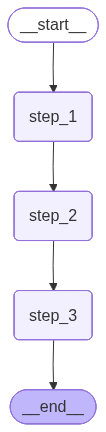

In [ ]:
#build the graph 
builder = StateGraph(CrashState)

builder.add_node('step_1',step_1)
builder.add_node('step_2',step_2)
builder.add_node('step_3',step_3)


builder.add_edge(START,'step_1')
builder.add_edge('step_1','step_2')
builder.add_edge('step_2','step_3')
builder.add_edge('step_3',END)

checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)
graph


In [ ]:
try: 
    print('Running graph: please manually interrupt during step 2')
    graph.invoke({'input':'start'},config={'configurable':{'thread_id':'1'}})
except KeyboardInterrupt: 
    print('Kernal manually interrupted: (crash simulation... )')

Running graph: please manually interrupt during step 2
step 1: executed
step 2 hanging ... now manually interrupt from the notebook toolbar (STOP button)
Kernal manually interrupted: (crash simulation... )


In [ ]:
config = {'configurable': {'thread_id': '1'}}
graph.get_state(config)

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e3a-6b85-8001-b9c2431ed1e4'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-15T17:46:04.762400+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e39-660e-8000-de8ad5760c6d'}}, tasks=(PregelTask(id='c5d3db4f-8a89-3eb6-610b-ff51698254ca', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [ ]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e3a-6b85-8001-b9c2431ed1e4'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-15T17:46:04.762400+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e39-660e-8000-de8ad5760c6d'}}, tasks=(PregelTask(id='c5d3db4f-8a89-3eb6-610b-ff51698254ca', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e39-660e-8000-de8ad5760c6d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-15T17:46:04.761851+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e37

## ***Fault Tolerance***

In [ ]:
#  6. Re-run o show fault tolerance resume 
final_state = graph.invoke(None,config=config)

step 2 hanging ... now manually interrupt from the notebook toolbar (STOP button)
step 3 : executed


In [ ]:
print(final_state)

{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': True}


In [ ]:
graph.get_state(config)

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': True}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1209ee-8ae9-6c0c-8003-cc23eb15f188'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-15T18:43:50.587462+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1209ee-8ae3-6732-8002-c3fd9cc07e40'}}, tasks=(), interrupts=())

In [ ]:
list(graph.get_state_history(config))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': True}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1209ee-8ae9-6c0c-8003-cc23eb15f188'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-15T18:43:50.587462+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1209ee-8ae3-6732-8002-c3fd9cc07e40'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1209ee-8ae3-6732-8002-c3fd9cc07e40'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-15T18:43:50.584868+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12096d-6e3a-6b85-8001-b9c2431ed1e4'}}, tasks=(PregelTask(id='b259adfb-0d86-6b75-b02b-1c8d8de2d4b1', name='ste

# ***Time Travel***

In [95]:
config1 = {"configurable": {"thread_id": "4"}}
workflow.invoke({'topic':'pizza'}, config=config1)

joke : [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can be topped!', 'extras': {'signature': 'EssTCsgTAb4+9vvHYiCz+eamWfK162KrKuDm75Uco14EDIOuGQFOWsw2tSCsa+uvLRVe8/m5onhy3N1G4b+snPjaCmW1ZDBMX2CSJBlHbNpvLR/hcxBnpuPtXSQMh1R4qZSUXY7cea0Po9ENFnrNPJk1zNEtBC5bsatcFjtLFYVi5Vj4UYV5MOib6kBonbD8a/VJC0uxTtRBzRMTZw5R4jUD5+qPw7Xr8UutOsMVx43XRHaGJKEObGLaMcDOsYoQG2QknD43GwN4OES4yKNd2Tt4W4XDmEepgexxudxHQlfwtUkPaNRhYfGvtoJHjb5umj73AddnSFUU5TdvI3AN7V24n3oC10yyFrF7egW5Evil+Xylbf7bW9sSJpTjAirVq8VsopS7gbEqcsyOU9778xPR3aUnulIAvlasYAqOzLoZkjitTGymF1xnj+G/Mu2ShTnfOIGdC6p9hU9vXTzFJPUdqvRTbpbtdrp0q6r+xS//hEOND9gtfAtrn+t48d/3ZrspHP2nKlosWVzqFv64O08vxolCMDjdZqucJ5HejyJnW/ESFvzV/gYiG/sDV0RilW5RgEbp7lKykemtyReV2SEStumAL1OV8tpbXQClqbkbE5AdxAYneQlrsswduSCuEJJhHPixSyHeAE9eA1F2tXWJhJr7PJchRo72t6C2/dnsN6lgrrwHcuz/ZJ/vNs7epjJsbmlwAsMlmnggWfAZjeygbcsXC4TD71Yjcjml3xpgUTRRyzvJi/XCSi5TFJ0g6LzsvGq5loqyfGcE9P/bMC62K3G/QYxqCEKc8te3YFY5mt0G/tRNDwQL+Lt/5zsfHxaoA0ZtWMYcmGIx+4izSDoQS+Pms

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can be topped!',
   'extras': {'signature': 'EssTCsgTAb4+9vvHYiCz+eamWfK162KrKuDm75Uco14EDIOuGQFOWsw2tSCsa+uvLRVe8/m5onhy3N1G4b+snPjaCmW1ZDBMX2CSJBlHbNpvLR/hcxBnpuPtXSQMh1R4qZSUXY7cea0Po9ENFnrNPJk1zNEtBC5bsatcFjtLFYVi5Vj4UYV5MOib6kBonbD8a/VJC0uxTtRBzRMTZw5R4jUD5+qPw7Xr8UutOsMVx43XRHaGJKEObGLaMcDOsYoQG2QknD43GwN4OES4yKNd2Tt4W4XDmEepgexxudxHQlfwtUkPaNRhYfGvtoJHjb5umj73AddnSFUU5TdvI3AN7V24n3oC10yyFrF7egW5Evil+Xylbf7bW9sSJpTjAirVq8VsopS7gbEqcsyOU9778xPR3aUnulIAvlasYAqOzLoZkjitTGymF1xnj+G/Mu2ShTnfOIGdC6p9hU9vXTzFJPUdqvRTbpbtdrp0q6r+xS//hEOND9gtfAtrn+t48d/3ZrspHP2nKlosWVzqFv64O08vxolCMDjdZqucJ5HejyJnW/ESFvzV/gYiG/sDV0RilW5RgEbp7lKykemtyReV2SEStumAL1OV8tpbXQClqbkbE5AdxAYneQlrsswduSCuEJJhHPixSyHeAE9eA1F2tXWJhJr7PJchRo72t6C2/dnsN6lgrrwHcuz/ZJ/vNs7epjJsbmlwAsMlmnggWfAZjeygbcsXC4TD71Yjcjml3xpgUTRRyzvJi/XCSi5TFJ0g6LzsvGq5loqyfGcE9P/bMC62K3G/QYxqCEKc8te3YFY5mt0G/tRNDwQL+Lt/5zsfHx

In [97]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can be topped!', 'extras': {'signature': 'EssTCsgTAb4+9vvHYiCz+eamWfK162KrKuDm75Uco14EDIOuGQFOWsw2tSCsa+uvLRVe8/m5onhy3N1G4b+snPjaCmW1ZDBMX2CSJBlHbNpvLR/hcxBnpuPtXSQMh1R4qZSUXY7cea0Po9ENFnrNPJk1zNEtBC5bsatcFjtLFYVi5Vj4UYV5MOib6kBonbD8a/VJC0uxTtRBzRMTZw5R4jUD5+qPw7Xr8UutOsMVx43XRHaGJKEObGLaMcDOsYoQG2QknD43GwN4OES4yKNd2Tt4W4XDmEepgexxudxHQlfwtUkPaNRhYfGvtoJHjb5umj73AddnSFUU5TdvI3AN7V24n3oC10yyFrF7egW5Evil+Xylbf7bW9sSJpTjAirVq8VsopS7gbEqcsyOU9778xPR3aUnulIAvlasYAqOzLoZkjitTGymF1xnj+G/Mu2ShTnfOIGdC6p9hU9vXTzFJPUdqvRTbpbtdrp0q6r+xS//hEOND9gtfAtrn+t48d/3ZrspHP2nKlosWVzqFv64O08vxolCMDjdZqucJ5HejyJnW/ESFvzV/gYiG/sDV0RilW5RgEbp7lKykemtyReV2SEStumAL1OV8tpbXQClqbkbE5AdxAYneQlrsswduSCuEJJhHPixSyHeAE9eA1F2tXWJhJr7PJchRo72t6C2/dnsN6lgrrwHcuz/ZJ/vNs7epjJsbmlwAsMlmnggWfAZjeygbcsXC4TD71Yjcjml3xpgUTRRyzvJi/XCSi5TFJ0g6LzsvGq5loqyfGcE9P/bMC62K3G/QYxqCEKc8te3YFY5mt0G/tRN

In [98]:
state_history = list(workflow.get_state_history(config1))
state_history

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can be topped!', 'extras': {'signature': 'EssTCsgTAb4+9vvHYiCz+eamWfK162KrKuDm75Uco14EDIOuGQFOWsw2tSCsa+uvLRVe8/m5onhy3N1G4b+snPjaCmW1ZDBMX2CSJBlHbNpvLR/hcxBnpuPtXSQMh1R4qZSUXY7cea0Po9ENFnrNPJk1zNEtBC5bsatcFjtLFYVi5Vj4UYV5MOib6kBonbD8a/VJC0uxTtRBzRMTZw5R4jUD5+qPw7Xr8UutOsMVx43XRHaGJKEObGLaMcDOsYoQG2QknD43GwN4OES4yKNd2Tt4W4XDmEepgexxudxHQlfwtUkPaNRhYfGvtoJHjb5umj73AddnSFUU5TdvI3AN7V24n3oC10yyFrF7egW5Evil+Xylbf7bW9sSJpTjAirVq8VsopS7gbEqcsyOU9778xPR3aUnulIAvlasYAqOzLoZkjitTGymF1xnj+G/Mu2ShTnfOIGdC6p9hU9vXTzFJPUdqvRTbpbtdrp0q6r+xS//hEOND9gtfAtrn+t48d/3ZrspHP2nKlosWVzqFv64O08vxolCMDjdZqucJ5HejyJnW/ESFvzV/gYiG/sDV0RilW5RgEbp7lKykemtyReV2SEStumAL1OV8tpbXQClqbkbE5AdxAYneQlrsswduSCuEJJhHPixSyHeAE9eA1F2tXWJhJr7PJchRo72t6C2/dnsN6lgrrwHcuz/ZJ/vNs7epjJsbmlwAsMlmnggWfAZjeygbcsXC4TD71Yjcjml3xpgUTRRyzvJi/XCSi5TFJ0g6LzsvGq5loqyfGcE9P/bMC62K3G/QYxqCEKc8te3YFY5mt0G/tR

In [99]:
checkpoint_id = "1f120a22-79c8-6a89-8000-6d7a5de67da5"
workflow.get_state({'configurable':{'thread_id':'1','checkpoint_id':checkpoint_id}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f120a22-79c8-6a89-8000-6d7a5de67da5'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-15T19:07:04.655722+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f120a22-79c7-60d8-bfff-5c4f43acb99a'}}, tasks=(PregelTask(id='3fe17c3e-4c45-9c80-7912-77e2647c43ba', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can feed a family of four.', 'extras': {'signature': 'EoMSCoASAb4+9vtj9a1Be9US3H4SdudsX+HyWn2sk4aiYLuJXv8OSP/Xa7qpDZZFRxT1vtAf4RBJu0465J8IMTHlBpR3c+QOd7UYDAmz5xj7oYI4usFKo0QKlwEr1xz+slThHRJ8wD88YpS/vHGAzALxM206GBtQ8p21k1W8LPySPxWamsoY+02QVzuoXHiObUDqZNdlWeN7jsqXylps29hAE/YUgbPAFn5JQ+JZ6luSfYklXAqb0m987ou0XLF8HNPz+c9mw3FSplEPKTZ5b

In [100]:
workflow.invoke(None,{'configurable':{'thread_id':'1','checkpoint_id':checkpoint_id}})

joke : [{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith tomato paste!', 'extras': {'signature': 'Et8MCtwMAb4+9vvIW+0J0Hl4JRbWeg9mWdOnVKIanPQMV+DyHWr1e2XIBq5mw01resp9KoN2eeskgtqhMaDtYdXhJtXGMlpAnpL4YwBlasNFEiEExFw9pb9lOZIpwACZjjV3ZjSmE0wBVsjABXxPIiYaMhbZEvbP9CvMJHBMgxaKKs0BjwPTByDLyg3SiFdii4iG8Ej1jT/fpSgmSeNCupKkwXIZJCpypFbgtODsmixdrame2KeJjtkr+5pqlt0dABPvsI5v5Qxn9asDA2Y8OgnUUqwg3cPboCzy6fD6+QiGzScMnTqTW222rKhzAMi5FZmb4k3a4YQwxsr5AueRy+RAL+VrwY59E2RfB9JZFxtPBsyw6M0EXnDYU8IGEaJm6WCOH3UzqN13GX2dwuHfX9C6+7nN1bNgEwZd/0KGYMn7hzT6Y4yBV7AuyU/7kfyDW5/nBX/Ck9PYEYeI2/1q+VLKa8DmNBqQdJvfP4YBpgXAAzbM1T1HMH3yOGnEjWoltFFlapR3nvqbvULWsLCjX2ZG0JL+YzAKE6nr6i63aLoDxcyOTZFQ+a7B5pENGX/vPhSBnonyDg5zZFCceUbRBqu/2vmuo6TdLAv8zlaBV8/4llJTAR0kHLwWAbrpyW8sMdUdZMuz+WoweRq1AR3Ar9TtBee0SzdRKSOuypAADC3mHYMgnJ5OT1uTM2M7JzLqiWbwqIG87Bo4vumHNMk6iQ1SjHVhKZ6HkIoi+zBJM4HjTM7sj8Nssp/bUjoozyS6oPe4Bg4tb9ON5soiUlNpeNj+9c4m7Yi+50oRBW6QBk2UXFxBiVXpnFMcer+o8dl6lO+XmrPjvRlEFlKYKprA/YYjKwzgyMRah6AVA9osgny7dPbnMPhQte

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'How do you fix a broken pizza?\n\nWith tomato paste!',
   'extras': {'signature': 'Et8MCtwMAb4+9vvIW+0J0Hl4JRbWeg9mWdOnVKIanPQMV+DyHWr1e2XIBq5mw01resp9KoN2eeskgtqhMaDtYdXhJtXGMlpAnpL4YwBlasNFEiEExFw9pb9lOZIpwACZjjV3ZjSmE0wBVsjABXxPIiYaMhbZEvbP9CvMJHBMgxaKKs0BjwPTByDLyg3SiFdii4iG8Ej1jT/fpSgmSeNCupKkwXIZJCpypFbgtODsmixdrame2KeJjtkr+5pqlt0dABPvsI5v5Qxn9asDA2Y8OgnUUqwg3cPboCzy6fD6+QiGzScMnTqTW222rKhzAMi5FZmb4k3a4YQwxsr5AueRy+RAL+VrwY59E2RfB9JZFxtPBsyw6M0EXnDYU8IGEaJm6WCOH3UzqN13GX2dwuHfX9C6+7nN1bNgEwZd/0KGYMn7hzT6Y4yBV7AuyU/7kfyDW5/nBX/Ck9PYEYeI2/1q+VLKa8DmNBqQdJvfP4YBpgXAAzbM1T1HMH3yOGnEjWoltFFlapR3nvqbvULWsLCjX2ZG0JL+YzAKE6nr6i63aLoDxcyOTZFQ+a7B5pENGX/vPhSBnonyDg5zZFCceUbRBqu/2vmuo6TdLAv8zlaBV8/4llJTAR0kHLwWAbrpyW8sMdUdZMuz+WoweRq1AR3Ar9TtBee0SzdRKSOuypAADC3mHYMgnJ5OT1uTM2M7JzLqiWbwqIG87Bo4vumHNMk6iQ1SjHVhKZ6HkIoi+zBJM4HjTM7sj8Nssp/bUjoozyS6oPe4Bg4tb9ON5soiUlNpeNj+9c4m7Yi+50oRBW6QBk2UXFxBiVXpnFMcer+o8dl6lO+XmrPjvRlEFlKYKprA/YYjKwz

In [101]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'What’s the difference between a pizza and my jokes?\n\nA pizza can be topped!', 'extras': {'signature': 'EssTCsgTAb4+9vvHYiCz+eamWfK162KrKuDm75Uco14EDIOuGQFOWsw2tSCsa+uvLRVe8/m5onhy3N1G4b+snPjaCmW1ZDBMX2CSJBlHbNpvLR/hcxBnpuPtXSQMh1R4qZSUXY7cea0Po9ENFnrNPJk1zNEtBC5bsatcFjtLFYVi5Vj4UYV5MOib6kBonbD8a/VJC0uxTtRBzRMTZw5R4jUD5+qPw7Xr8UutOsMVx43XRHaGJKEObGLaMcDOsYoQG2QknD43GwN4OES4yKNd2Tt4W4XDmEepgexxudxHQlfwtUkPaNRhYfGvtoJHjb5umj73AddnSFUU5TdvI3AN7V24n3oC10yyFrF7egW5Evil+Xylbf7bW9sSJpTjAirVq8VsopS7gbEqcsyOU9778xPR3aUnulIAvlasYAqOzLoZkjitTGymF1xnj+G/Mu2ShTnfOIGdC6p9hU9vXTzFJPUdqvRTbpbtdrp0q6r+xS//hEOND9gtfAtrn+t48d/3ZrspHP2nKlosWVzqFv64O08vxolCMDjdZqucJ5HejyJnW/ESFvzV/gYiG/sDV0RilW5RgEbp7lKykemtyReV2SEStumAL1OV8tpbXQClqbkbE5AdxAYneQlrsswduSCuEJJhHPixSyHeAE9eA1F2tXWJhJr7PJchRo72t6C2/dnsN6lgrrwHcuz/ZJ/vNs7epjJsbmlwAsMlmnggWfAZjeygbcsXC4TD71Yjcjml3xpgUTRRyzvJi/XCSi5TFJ0g6LzsvGq5loqyfGcE9P/bMC62K3G/QYxqCEKc8te3YFY5mt0G/tR

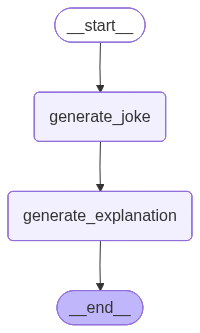

In [91]:
workflow

# ***Updating State***

In [105]:
config4 = {'configurable':{'thread_id':'4'}}
workflow.update_state({'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f120a6a-fbcf-6a15-8000-7e8d987cd593'}},{'topic':'samosa'})

{'configurable': {'thread_id': '4',
  'checkpoint_ns': '',
  'checkpoint_id': '1f120a74-1ef0-6107-8001-0954e06e3613'}}

In [106]:
list(workflow.get_state_history(config4))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f120a74-1ef0-6107-8001-0954e06e3613'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-15T19:43:36.300555+00:00', parent_config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f120a6a-fbcf-6a15-8000-7e8d987cd593'}}, tasks=(PregelTask(id='2dbce26a-ce0d-b44b-d34d-9e708b0c6979', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f120a71-44a0-6351-8001-cbe3a216fe12'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-15T19:42:19.721799+00:00', parent_config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id

In [109]:
workflow.invoke(None,{'configurable':{'thread_id':'4','checkpoint_id':'1f120a71-44a0-6351-8001-cbe3a216fe12'}})

joke : [{'type': 'text', 'text': 'Why is it so hard to argue with a samosa?\n\nBecause it always makes **three good points**!', 'extras': {'signature': 'EsMUCsAUAb4+9vuAQMuWa+xb38SCe6n1WyGz2/+vJSQiRAeO0Vn8wxaH79NDgnBaOdgw56o19+/uwNipyBRfkWOMHYVR3m1gILF/EpmaSkjAENcL79oOhYndvF//r8vEOsAUA96vDqfU8VGw++r/eg2J/IVzwjSKCFJa45lvy2WDDPTcdAWHeXlj7qQ//lewuo1pI+Rj+lijfeSWhw1Ia67yfFKXRKWqiMceWyHEyI7Hm+qkxAN4VDBroGH/NJyGLijXMjB/pV+T60wmRNM2qLtX+9aXalpPOVWcmMhGsijrk12R2j7fRt1Qr2nx6aOtfn9GucJVepZLqX4cdVk2NwxFlo1rB5X3fosDoksTMGdW2NmY7jtdc/uJE4C+dJaHa4ILZuqlFsBnt2HdVApoM7e2Ztw9xaYv8t8regE7OpE8nkBqS0vq/uZy5JhUEGNlszKpjyWuaH4RgrVYuNn7s0dOj1WbRgLPiH3hZXqOJCKO5W97MuVEh7wh3bPbyzHpCB1j5GHgiUUrOmdeZ8CcX63siDU0Wam0hgghy+H5ZTipxRnYdV7wVwkOWw2zAJaymPETTClYttFHm1qhLrzXl8tlijXb0anWGv4q2rVEbnAFmuPE/eiANTzmj0r4bn0qMmXOXyXqX08vhS1uSn4k5TLND5PAIBqxzYtqsk4+HG6Uvn5jWtx3wKZkJxu+tbJv9CsfMKYRbydpt703//50AJJQQwlKXugelR7SGyc1t3cbe3OE/To5/ipmYqd7EzPZtPAwRM/RgpK6OKBMHCAtpGhC5eYk3HLCljJIhtdupcBgeuZfT/g8dYlT2m5FooVPu1U7Ps/m1qnmYeR

{'topic': 'samosa',
 'joke': [{'type': 'text',
   'text': 'Why is it so hard to argue with a samosa?\n\nBecause it always makes **three good points**!',
   'extras': {'signature': 'EsMUCsAUAb4+9vuAQMuWa+xb38SCe6n1WyGz2/+vJSQiRAeO0Vn8wxaH79NDgnBaOdgw56o19+/uwNipyBRfkWOMHYVR3m1gILF/EpmaSkjAENcL79oOhYndvF//r8vEOsAUA96vDqfU8VGw++r/eg2J/IVzwjSKCFJa45lvy2WDDPTcdAWHeXlj7qQ//lewuo1pI+Rj+lijfeSWhw1Ia67yfFKXRKWqiMceWyHEyI7Hm+qkxAN4VDBroGH/NJyGLijXMjB/pV+T60wmRNM2qLtX+9aXalpPOVWcmMhGsijrk12R2j7fRt1Qr2nx6aOtfn9GucJVepZLqX4cdVk2NwxFlo1rB5X3fosDoksTMGdW2NmY7jtdc/uJE4C+dJaHa4ILZuqlFsBnt2HdVApoM7e2Ztw9xaYv8t8regE7OpE8nkBqS0vq/uZy5JhUEGNlszKpjyWuaH4RgrVYuNn7s0dOj1WbRgLPiH3hZXqOJCKO5W97MuVEh7wh3bPbyzHpCB1j5GHgiUUrOmdeZ8CcX63siDU0Wam0hgghy+H5ZTipxRnYdV7wVwkOWw2zAJaymPETTClYttFHm1qhLrzXl8tlijXb0anWGv4q2rVEbnAFmuPE/eiANTzmj0r4bn0qMmXOXyXqX08vhS1uSn4k5TLND5PAIBqxzYtqsk4+HG6Uvn5jWtx3wKZkJxu+tbJv9CsfMKYRbydpt703//50AJJQQwlKXugelR7SGyc1t3cbe3OE/To5/ipmYqd7EzPZtPAwRM/RgpK6OKBMHCAtpGhC5eYk3HLCljJIhtdupcBgeuZfT/g

In [110]:
list(workflow.get_state_history(config4))

[StateSnapshot(values={'topic': 'samosa', 'joke': [{'type': 'text', 'text': 'Why is it so hard to argue with a samosa?\n\nBecause it always makes **three good points**!', 'extras': {'signature': 'EsMUCsAUAb4+9vuAQMuWa+xb38SCe6n1WyGz2/+vJSQiRAeO0Vn8wxaH79NDgnBaOdgw56o19+/uwNipyBRfkWOMHYVR3m1gILF/EpmaSkjAENcL79oOhYndvF//r8vEOsAUA96vDqfU8VGw++r/eg2J/IVzwjSKCFJa45lvy2WDDPTcdAWHeXlj7qQ//lewuo1pI+Rj+lijfeSWhw1Ia67yfFKXRKWqiMceWyHEyI7Hm+qkxAN4VDBroGH/NJyGLijXMjB/pV+T60wmRNM2qLtX+9aXalpPOVWcmMhGsijrk12R2j7fRt1Qr2nx6aOtfn9GucJVepZLqX4cdVk2NwxFlo1rB5X3fosDoksTMGdW2NmY7jtdc/uJE4C+dJaHa4ILZuqlFsBnt2HdVApoM7e2Ztw9xaYv8t8regE7OpE8nkBqS0vq/uZy5JhUEGNlszKpjyWuaH4RgrVYuNn7s0dOj1WbRgLPiH3hZXqOJCKO5W97MuVEh7wh3bPbyzHpCB1j5GHgiUUrOmdeZ8CcX63siDU0Wam0hgghy+H5ZTipxRnYdV7wVwkOWw2zAJaymPETTClYttFHm1qhLrzXl8tlijXb0anWGv4q2rVEbnAFmuPE/eiANTzmj0r4bn0qMmXOXyXqX08vhS1uSn4k5TLND5PAIBqxzYtqsk4+HG6Uvn5jWtx3wKZkJxu+tbJv9CsfMKYRbydpt703//50AJJQQwlKXugelR7SGyc1t3cbe3OE/To5/ipmYqd7EzPZtPAwRM/RgpK6OKBMHCAtpGhC5eYk3HLCljJI